# Ridge Regression Cross-Sectional Return Predictor

Walk-forward backtest using Ridge regression on the full S&P 500 universe.
Results (charts + tables) are saved to `results/linear_regression_expanding/`.

Uses the same features, target, and backtest configuration as `xgboost.ipynb` for a fair comparison.

In [8]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '../../src')

from evaluation import WalkForwardExpandingBacktester, WalkForwardSlidingBacktester
from features.registry import FeatureStore
from models import RidgeRankModel
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1  Data Loading

In [12]:
store = FeatureStore('../../data/features/yahoo_S&P_500')
store.describe()
features_df = store.load()
features_df = features_df.reset_index().set_index('Date')

KeyboardInterrupt: 

In [ ]:
features_df.columns

## 2  Features & Target

In [3]:
FEATURES = [
    'amihud_21',
    'ivol_252',
    'parkinsons_vol_63',
    'downside_dev_21',
    'mom_252_756',
    'mom_126_252',
    'max_21',
    'rolling_beta',
    'mom_1_21',
]

features_df = features_df[FEATURES + ['Ticker']]
features_df[FEATURES] = features_df[FEATURES].groupby('Date').transform(lambda x: x.rank(pct=True))

## 3  Build Panel

In [4]:
_temp_df = pd.read_parquet('../../data/raw/yahoo_S&P_500/raw.parquet')
_temp_df = _temp_df.reset_index().set_index('Date').sort_index()
adj = _temp_df["Adj Close"].sort_index()
fwd_ret = adj.pct_change(21, fill_method=None).shift(-21)
del _temp_df

fwd_ret = fwd_ret.stack().reset_index()
fwd_ret.columns = ['Date', 'Ticker', 'target']
fwd_ret = fwd_ret.set_index('Date')
fwd_ret['target'] = fwd_ret['target'].groupby('Date').transform(lambda x: x.rank(pct=True))

df = pd.merge(
    features_df.reset_index(),
    fwd_ret.reset_index(),
    on=['Date', 'Ticker'],
    how='left',
).set_index('Date')

days = df.index.sort_values()
t0_id = sum(days < days[0] + pd.DateOffset(years=3, days=5))
df = df[df.index > days[t0_id]]
print(f"Panel: {df.shape}  |  {df.index.min().date()} → {df.index.max().date()}")

Panel: (2540958, 11)  |  2004-01-08 → 2026-03-30


## 4  Walk-Forward Backtest

In [9]:
MODEL_NAME = "linear_regression_sliding"
RESULTS_DIR = "../../results/linear_regression_sliding"

model = RidgeRankModel(alpha=1.0)

"""backtester = WalkForwardExpandingBacktester(
    model=model,
    initial_train_months=84,
    test_months=1,
    step_months=1,
    embargo_days=21,
)"""

backtester = WalkForwardSlidingBacktester(
    model=model,
    window_size=84,
    test_months=1,
    step_months=1,
    embargo_days=21,
)


results = backtester.run(df, feature_cols=FEATURES, target_col="target")
print(f"Completed {len(results)} folds.")

Walk-forward [linear_regression]:  68%|██████▊   | 182/267 [00:32<00:15,  5.56it/s]

Completed 181 folds.


## 5  Diagnostics — IC, ICIR, L/S Spread

    CROSS-SECTIONAL DIAGNOSTIC  [LINEAR_REGRESSION_SLIDING]
  Period:            2011-02-08 → 2026-02-18
  # Cross-sections:  177

  Mean IC:           0.0264
  IC Std:            0.1605
  ICIR:              0.1642
  IC t-stat (NW):    2.40  (p=0.0174)
  Hit Rate:          58.2%  (% months IC > 0)

  Mean L/S Spread:   0.0201  (rank units)
  L/S Hit Rate:      57.6%

  ✓ IC is statistically significant (NW |t| > 2)
  ~ Mean IC 0.02–0.05 — acceptable, typical in practice
  ~ ICIR < 0.5 — high variability in monthly performance

  Charts saved to ../../results/linear_regression_sliding/charts
  Tables saved to ../../results/linear_regression_sliding/tables


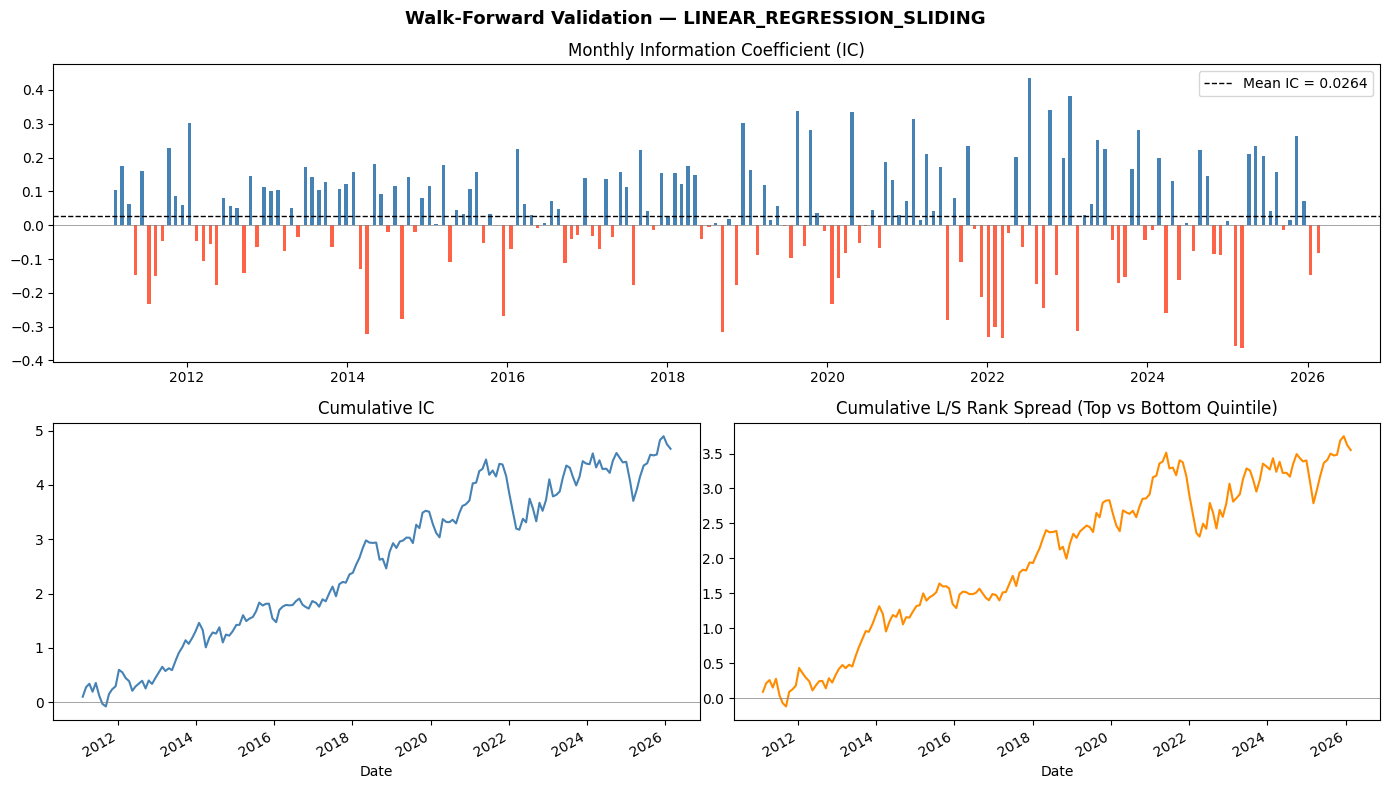

In [10]:
ic_series, ls_spread = utils.diagnose(
    results,
    ic_on_every=21,
    save_dir=RESULTS_DIR,
    model_name=MODEL_NAME,
)

## 6  Feature Importance (Ridge Coefficients)

  Feature importance chart saved to ../../results/linear_regression_sliding/charts


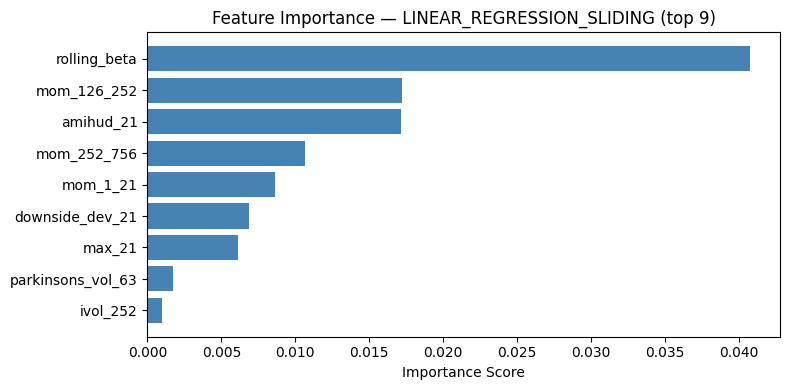

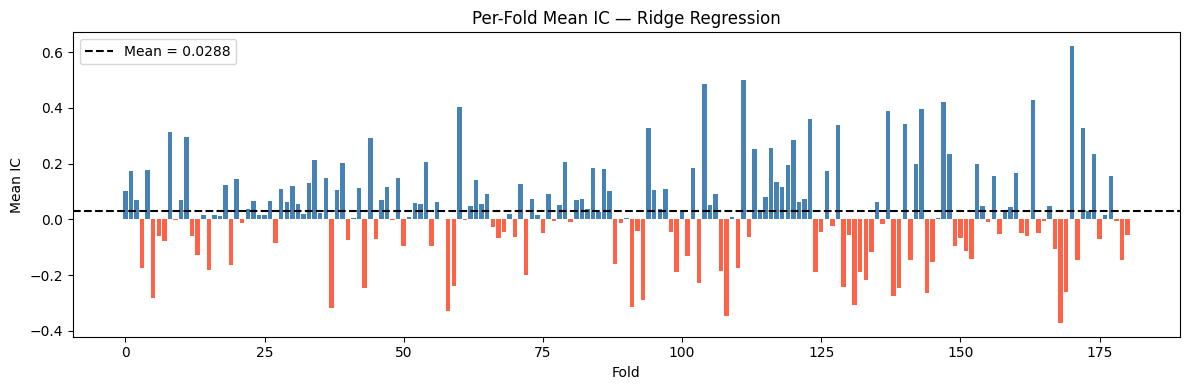

In [11]:
importance = model.get_feature_importance()
if importance is not None:
    fig = utils.plot_feature_importance(
        importance, model_name=MODEL_NAME, top_n=len(FEATURES), save_dir=RESULTS_DIR
    )
    plt.show()

# Per-fold IC bar chart
fold_ics = []
for r in results:
    from scipy.stats import spearmanr
    df_fold = pd.DataFrame({"pred": r["preds"], "actual": r["actuals"]}, index=r["index"])
    sampled = df_fold.index.unique().sort_values()[::21]
    df_s = df_fold[df_fold.index.isin(sampled)]
    ic = df_s.groupby("Date").apply(lambda x: x["pred"].corr(x["actual"], method="spearman")).mean()
    fold_ics.append({"fold": r["fold"], "test_start": r["test_start"], "mean_ic": ic})

fold_ic_df = pd.DataFrame(fold_ics)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["steelblue" if v > 0 else "tomato" for v in fold_ic_df["mean_ic"]]
ax.bar(fold_ic_df["fold"], fold_ic_df["mean_ic"], color=colors)
ax.axhline(fold_ic_df["mean_ic"].mean(), color="black", linestyle="--",
           label=f'Mean = {fold_ic_df["mean_ic"].mean():.4f}')
ax.set_xlabel("Fold")
ax.set_ylabel("Mean IC")
ax.set_title("Per-Fold Mean IC — Ridge Regression")
ax.legend()
plt.tight_layout()

import pathlib
pathlib.Path(f"{RESULTS_DIR}/charts").mkdir(parents=True, exist_ok=True)
fig.savefig(f"{RESULTS_DIR}/charts/linear_regression_per_fold_ic.png", dpi=150, bbox_inches="tight")
fold_ic_df.to_csv(f"{RESULTS_DIR}/tables/linear_regression_per_fold_ic.csv", index=False)
plt.show()